# Assignment 4

Assume you work for a record company. Your boss is interested in predicting ablum sales based on advertising. You are provided with the data in a file (*album_sales.csv*). 

There are 200 rows, where each row represents an album. There are also four columns. The first (*sales*) represents the sales of each album (in thousands) the week after release. The second (adverts) represents the amount (in thousands $) spent promoting the album prior to its release. The third (*airplay*) represents how many times it played on the radio. The fourth column (*attract*) represents the attractiveness of the band. 

## Instructions

### 1. Visualization (15 points)

Visualizing data is important to get a 'feel' of what the relationship between variables could be. For this part, **display the scatterplots between the following variables**.

- *sales* and *adverts*
- *sales* and *airplay*
- *sales* and *attract*

     sales   adverts  airplay  attract
0      330    10.256       43       10
1      120   985.685       28        7
2      360  1445.563       35        7
3      270  1188.193       33        7
4      220   574.513       44        5
..     ...       ...      ...      ...
195    190   910.851       26        7
196    240   888.569       14        6
197    250   800.615       34        6
198    230  1500.000       11        8
199    110   785.694       20        9

[200 rows x 4 columns]


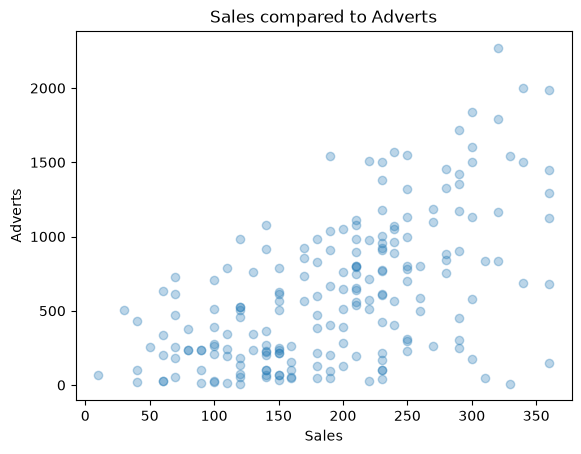

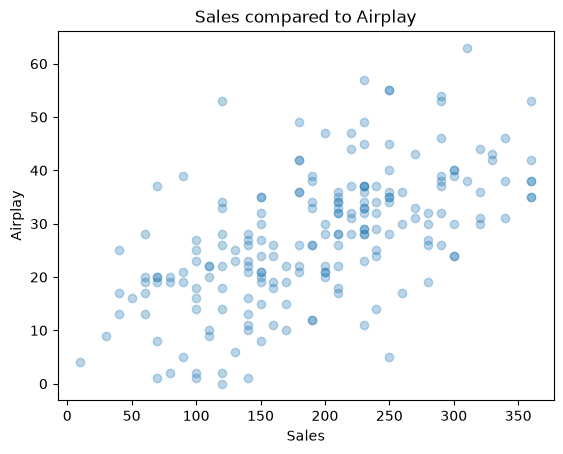

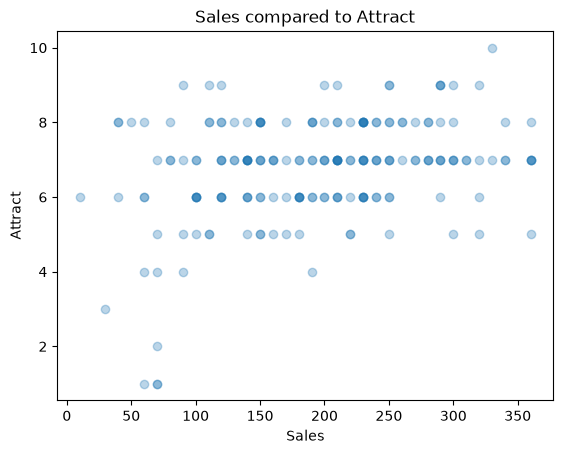

In [6]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('./album_sales.csv')
print(df)

plt.scatter(x = df['sales'], y = df['adverts'], alpha=0.3)
plt.title("Sales compared to Adverts")
plt.xlabel('Sales')
plt.ylabel("Adverts")
plt.show()

plt.scatter(x = df['sales'], y = df['airplay'], alpha=0.3)
plt.title("Sales compared to Airplay")
plt.xlabel('Sales')
plt.ylabel("Airplay")
plt.show()

plt.scatter(x = df['sales'], y = df['attract'], alpha=0.3)
plt.title("Sales compared to Attract")
plt.xlabel('Sales')
plt.ylabel("Attract")
plt.show()

In the empty `Markdown` cell below, describe the relationship (or lack thereof) portrayed by the scatterplots you generated. 

The relationship between sales and adverts seemed to be some kind of strong positive trend where as sales went up, so did adverts.

The relationship between sales and airplay also seemed to be a positive trend but stronger, where more sales means that it is likely to be airplayed more as well.

There does not seem to be a relationship between sales and attract, or if there is one it is extremely weak. For the most part, as sales went up attract stayed the same.

### 2. Linear Regression (35 points)

- Conduct a linear regression to construct a linear model between *sales* and *adverts*
- Display the **F-statistic** and **P-value**
    - Use the `statsmodels.api` module for this -- may need to install via `pip`
    - Note that **X**, your predictor(s), will consist of *adverts* and that **y**, your constant, will consist of *sales*
    - The values you need can be accessed via the `summary()` function of your model object

In [9]:
x = df['adverts']
y = df.sales
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x) # will be used later
print(model.summary())
print("F-statistic:", model.fvalue)
print("P-value:", model.f_pvalue)

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.331
Method:                 Least Squares   F-statistic:                     99.59
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           2.94e-19
Time:                        01:12:00   Log-Likelihood:                -1120.7
No. Observations:                 200   AIC:                             2245.
Df Residuals:                     198   BIC:                             2252.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        134.1399      7.537     17.799      0.0

In the empty `Markdown` cell below, describe whether the **F-statistic** and **P-value** describe about our linear regression model. (I.e., Is it good? Bad? No bearing?)

Our model has an F-statistic of 99.5868714961987 which is exremely high and a P-value of 2.941979852165935e-19 which is really low, meaning that there is a very signifigant relationship and that it is extremely unlikely for this data to exist by chance.

### 3. Model Coefficients (10 points)

- Make note of the **intercept** value and **coefficient** (adverts) value of your linear regression model. 

The regression line is described using this equation: *Y = b<sub>0</sub> + b<sub>1</sub>X<sub>1</sub>* where each variable represents the following:

- Y denotes the sales
- *b<sub>0</sub>* denotes the **intercept** value
- *b<sub>1</sub>* denotes the advertising budget **coefficient**
- *X<sub>2</sub>* denotes the advertising budget

The equation then becomes *Album Sales = intercept value + (coefficient * advertising budget)*. 

Using the intercept value and coefficient of your linear model, **calculate and display how many records will be sold if $135,000 was spent on advertising an album**.

In [12]:
intercept = model.params['const']
coefficient = model.params['adverts']

print("Intercept:", intercept)
print("Coefficient:", coefficient)

advertising_budget = 135
album_sales = intercept + (coefficient * advertising_budget)

print("Predicted sales is $135,000 was spent on advertising: ", album_sales)

Intercept: 134.13993781207427
Coefficient: 0.09612448597387711
Predicted sales is $135,000 was spent on advertising:  147.11674341854768


### 4. Multiple Regression (40 points)
- Conduct a **multiple regression** to construct a model between *sales* and the predictors (*adverts*, *airplay*, and *attract*)
    - Note that **X**, your predictors will consist of *adverts*, *airplay*, and *attractiveness*, and **y**, your constant, will consist of *sales*
- Display the summary of the multiple regression model using the `summary()` function to obtain the relevant values

In [13]:
x = df[['adverts', 'airplay', 'attract']]
y = df.sales
x = sm.add_constant(x)

model = sm.OLS(y, x).fit()
predictions = model.predict(x)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     129.5
Date:                Tue, 22 Sep 2026   Prob (F-statistic):           2.88e-46
Time:                        01:47:27   Log-Likelihood:                -1052.2
No. Observations:                 200   AIC:                             2112.
Df Residuals:                     196   BIC:                             2126.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -26.6130     17.350     -1.534      0.1

We know that the R<sup>2</sup> (R-Squared) value can be used to evaluate the overall fit of a linear model. We also know that R<sup>2</sup> is between 0 and 1 -- higher values are better because it means that more variance is explained by the model. **Higher R<sup>2</sup> values are better if their P-values are < 0.05**.

Bsed on this, discuss **which one of the two models you constructed is better** in the empty `Markdown` cell below. 
* Model 1: The linear model between *sales* and *adverts* you constructed
* Model 2: The multiple regression model between (*sales*) and the predictors (*adverts*, *airplay*, and *attract*) you constructed

Model 2 is constructed better because while both of the P-values are less than 0.05, Model 2 has an R-Squared value that is almost double Model 1. This means that Model 2 explains a lot more of the variance in the data and is thus better at predicting sales.

### Submission
- Submit this `Jupyter` file to D2L, renamed as **Last_First_Assignment4.ipynb** 
    - Replace '**Last**' and '**First**' with your first and last name